# 两层神经网络的梯度

In [ ]:
import numpy as np
from time import time
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softmax(x):
    """SoftMax"""
    c = np.max(x)
    exp_x = np.exp(x - c)
    sum_exp_x = np.sum(exp_x)
    return exp_x / sum_exp_x

def cross_entropy_error(y, t):
    """交叉熵误差"""
    delta = 1e-7
    return -np.sum(t * np.log(y + delta))


def numerical_gradient(f, x):
    """
    梯度计算
    """
    h = 1e-4 # 0.0001
    grad = np.zeros_like(x)
    
    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:
        idx = it.multi_index
        tmp_val = x[idx]
        x[idx] = float(tmp_val) + h
        fxh1 = f(x) # f(x+h)
        
        x[idx] = tmp_val - h 
        fxh2 = f(x) # f(x-h)
        grad[idx] = (fxh1 - fxh2) / (2*h)
        
        x[idx] = tmp_val # 还原值
        it.iternext()   
        
    return grad

class TwoLayerNet:
    def __init__(self, input_size, hidden_size, output_size) -> None:
        self.params = {}
        # W1: i * h 
        self.params['W1'] = np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        
        # W2: h * o
        self.params['W2'] = np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)
        
    def predict(self, x):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']
        
        a1 = np.dot(x, W1) + b1
        z = sigmoid(a1)
        a2 = np.dot(z, W2) + b2
        y = softmax(a2)
        return y
    
    def loss(self, x, t):
        y = self.predict(x)
        loss = cross_entropy_error(y, t)
        return loss
    
    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        t = np.argmax(t, axis=1)
        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy
    
    def numerical_gradient(self, x, t):
        loss_W = lambda W: self.loss(x, t)
        grads = {}
        grads['W1'] = numerical_gradient(loss_W, self.params['W1'])
        grads['b1'] = numerical_gradient(loss_W, self.params['b1'])
        grads['W2'] = numerical_gradient(loss_W, self.params['W2'])
        grads['b2'] = numerical_gradient(loss_W, self.params['b2'])
        return grads
    


In [2]:
# 加载数据集
import sys, os
sys.path.append(os.pardir)
sys.path.append(os.curdir)
from dataset.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, flatten=True, one_hot_label=True)


# 训练数据集和测试数据集都只取100条(缩短训练时间)
x_train, t_train = x_train[:100], t_train[:100]
x_test, t_test = x_test[:100], t_test[:100]

print(x_train.shape)
print(t_train.shape)
print(x_test.shape)
print(t_test.shape)


save_file: /Users/simeon/WorkSpace/Projects/Practice/RAGTest/test/../dataset/data/mnist.pkl
(100, 784)
(100, 10)
(100, 784)
(100, 10)


In [ ]:
def start_train(hidden_size, learning_rate, epoch_num):
    train_size = x_train.shape[0] # 训练数据集大小
    batch_size = min(100, train_size) # 批量大小
    
    net = TwoLayerNet(input_size=784, hidden_size=hidden_size, output_size=10)

    print("开始训练....")
    time_start = time()
    loss_list = []
    train_acc_list = []
    test_acc_list = []
    iter_per_epoch = max(train_size / batch_size, 1)
    
    current_epoch = 0

    for i in range(epoch_num):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]
        
        grad_numerical = net.numerical_gradient(x_batch, t_batch)
        for key in grad_numerical.keys():
            net.params[key] -= learning_rate * grad_numerical[key]
        
        # 记录每一次训练后的损失值变化
        loss = net.loss(x_batch, t_batch)
        loss_list.append(loss)
        
        if i % iter_per_epoch == 0:
            train_acc = net.accuracy(x_train, t_train)
            test_acc = net.accuracy(x_test, t_test)
            train_acc_list.append(train_acc)
            test_acc_list.append(test_acc)
            current_epoch += 1
            print(f"第{current_epoch}轮训练结束, 训练数据集正确率: {train_acc}, 测试数据集正确率: {test_acc}")

    print(f"训练结束, 用时: {time() - time_start}秒")
    print(f"在训练数据集省的正确率: {net.accuracy(x_train, t_train)}")
    print(f"在测试数据集上的正确率: {net.accuracy(x_test, t_test)}")
    
    # 设置字体为华文细黑
    plt.rcParams['font.sans-serif'] = ['STHeiti']  # macOS 上的华文细黑
    plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(train_acc_list, label="训练数据集正确率", color="blue")
    axes[0].plot(test_acc_list, label="测试数据集正确率", color="green")
    axes[0].set_xlabel("训练次数")
    axes[0].set_ylabel("正确率")
    axes[0].legend()

    axes[1].plot(loss_list, label="损失值", color="gray")
    axes[1].set_xlabel("训练次数")
    axes[1].set_ylabel("损失值")
    axes[1].legend()

    plt.show()


开始训练....
第1轮训练结束, 训练数据集正确率: 0.11, 测试数据集正确率: 0.08
第2轮训练结束, 训练数据集正确率: 0.16, 测试数据集正确率: 0.15
第3轮训练结束, 训练数据集正确率: 0.18, 测试数据集正确率: 0.13
第4轮训练结束, 训练数据集正确率: 0.29, 测试数据集正确率: 0.13
第5轮训练结束, 训练数据集正确率: 0.28, 测试数据集正确率: 0.15
第6轮训练结束, 训练数据集正确率: 0.21, 测试数据集正确率: 0.1
第7轮训练结束, 训练数据集正确率: 0.27, 测试数据集正确率: 0.07
第8轮训练结束, 训练数据集正确率: 0.36, 测试数据集正确率: 0.16
第9轮训练结束, 训练数据集正确率: 0.3, 测试数据集正确率: 0.12
第10轮训练结束, 训练数据集正确率: 0.44, 测试数据集正确率: 0.19
第11轮训练结束, 训练数据集正确率: 0.51, 测试数据集正确率: 0.16
第12轮训练结束, 训练数据集正确率: 0.59, 测试数据集正确率: 0.26
第13轮训练结束, 训练数据集正确率: 0.59, 测试数据集正确率: 0.27
第14轮训练结束, 训练数据集正确率: 0.55, 测试数据集正确率: 0.18
第15轮训练结束, 训练数据集正确率: 0.56, 测试数据集正确率: 0.17
第16轮训练结束, 训练数据集正确率: 0.56, 测试数据集正确率: 0.2
第17轮训练结束, 训练数据集正确率: 0.56, 测试数据集正确率: 0.26
第18轮训练结束, 训练数据集正确率: 0.76, 测试数据集正确率: 0.29
第19轮训练结束, 训练数据集正确率: 0.75, 测试数据集正确率: 0.29
第20轮训练结束, 训练数据集正确率: 0.81, 测试数据集正确率: 0.3
第21轮训练结束, 训练数据集正确率: 0.82, 测试数据集正确率: 0.25
第22轮训练结束, 训练数据集正确率: 0.83, 测试数据集正确率: 0.27
第23轮训练结束, 训练数据集正确率: 0.73, 测试数据集正确率: 0.2
第24轮训练结束, 训练数据集正确率: 0.84, 测试数据集正确率: 0.27
第25轮训练结束, 训练数据集正确率: 0

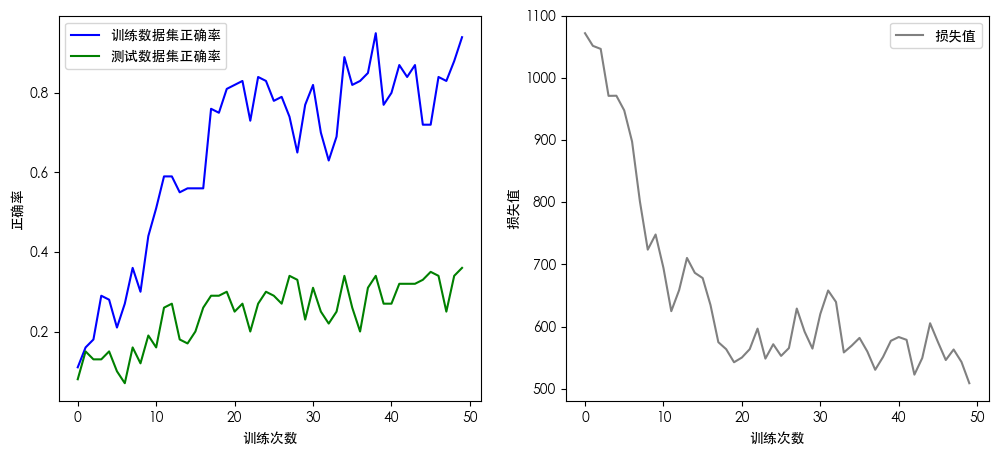

In [ ]:
# 超参数  
learning_rate = 0.01 # 学习率
epoch_num = 200 # 训练次数
hidden_size = 50 # 隐藏层大小
start_train(hidden_size, learning_rate, epoch_num)

开始训练....
第1轮训练结束, 训练数据集正确率: 0.19, 测试数据集正确率: 0.14
第2轮训练结束, 训练数据集正确率: 0.17, 测试数据集正确率: 0.08
第3轮训练结束, 训练数据集正确率: 0.17, 测试数据集正确率: 0.08
第4轮训练结束, 训练数据集正确率: 0.31, 测试数据集正确率: 0.21
第5轮训练结束, 训练数据集正确率: 0.3, 测试数据集正确率: 0.26
第6轮训练结束, 训练数据集正确率: 0.32, 测试数据集正确率: 0.18
第7轮训练结束, 训练数据集正确率: 0.31, 测试数据集正确率: 0.25
第8轮训练结束, 训练数据集正确率: 0.25, 测试数据集正确率: 0.17
第9轮训练结束, 训练数据集正确率: 0.2, 测试数据集正确率: 0.2
第10轮训练结束, 训练数据集正确率: 0.22, 测试数据集正确率: 0.2
第11轮训练结束, 训练数据集正确率: 0.19, 测试数据集正确率: 0.17
第12轮训练结束, 训练数据集正确率: 0.22, 测试数据集正确率: 0.17
第13轮训练结束, 训练数据集正确率: 0.24, 测试数据集正确率: 0.2
第14轮训练结束, 训练数据集正确率: 0.26, 测试数据集正确率: 0.21
第15轮训练结束, 训练数据集正确率: 0.32, 测试数据集正确率: 0.18
第16轮训练结束, 训练数据集正确率: 0.32, 测试数据集正确率: 0.18
第17轮训练结束, 训练数据集正确率: 0.37, 测试数据集正确率: 0.17
第18轮训练结束, 训练数据集正确率: 0.31, 测试数据集正确率: 0.17
第19轮训练结束, 训练数据集正确率: 0.26, 测试数据集正确率: 0.16
第20轮训练结束, 训练数据集正确率: 0.33, 测试数据集正确率: 0.18
第21轮训练结束, 训练数据集正确率: 0.27, 测试数据集正确率: 0.17
第22轮训练结束, 训练数据集正确率: 0.18, 测试数据集正确率: 0.14
第23轮训练结束, 训练数据集正确率: 0.28, 测试数据集正确率: 0.24
第24轮训练结束, 训练数据集正确率: 0.31, 测试数据集正确率: 0.19
第25轮训练结束, 训练数据集正确率: 0

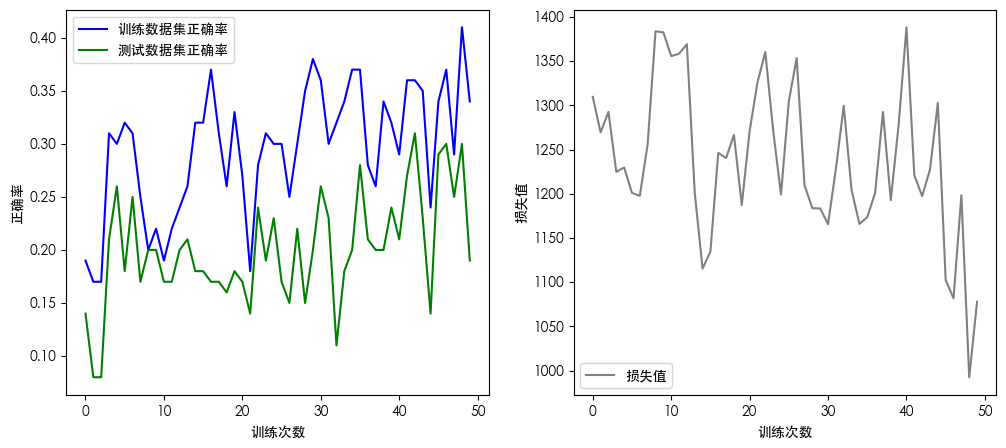

In [5]:
# 超参数  
learning_rate = 0.01 # 学习率
epoch_num = 200 # 训练次数
hidden_size = 100 # 隐藏层大小
start_train(hidden_size, learning_rate, epoch_num)